In [1]:
import numpy as np

In [2]:
class linear_Regression:
  def __init__ (self,learning_rate,no_of_iteration):
    self.learning_rate = learning_rate
    self.no_of_iteration = no_of_iteration


In [3]:
def __init__ (self,X,Y):
  self.m,self.n=X.shape
  self.w=np.zeros(self.n)
  self.b=0
  self.X=X
  self.Y=Y

In [4]:
class linear_Regression:
  def __init__ (self, learning_rate, no_of_iteration):
    self.learning_rate = learning_rate
    self.no_of_iteration = no_of_iteration
    self.m = None
    self.n = None
    self.w = None
    self.b = None
    self.X = None
    self.Y = None

  def fit(self, X, Y):
    self.X = X
    self.Y = Y
    self.m, self.n = X.shape
    self.w = np.zeros(self.n)
    self.b = 0

    for _ in range(self.no_of_iteration):
      self.update_weights()

  def update_weights(self):
    Y_pred = self.predict(self.X)
    dw = (1/self.m) * np.dot(self.X.T, (Y_pred - self.Y))
    db = (1/self.m) * np.sum(Y_pred - self.Y)
    self.w = self.w - self.learning_rate * dw
    self.b = self.b - self.learning_rate * db

  def predict(self, X):
    return X.dot(self.w) + self.b

## Data Loading and Preprocessing

In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/Salary_Data.csv')

# Display the first 5 rows of the dataset
print("First 5 rows of the dataset:")
display(df.head())

# Display basic information about the dataset
print("\nInformation about the dataset:")
df.info()

First 5 rows of the dataset:


,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0



Information about the dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


### Splitting the data into features (X) and target (Y)

In [6]:
# Assuming 'YearsExperience' is the feature and 'Salary' is the target
X = df['YearsExperience'].values.reshape(-1, 1) # Reshape for single feature
Y = df['Salary'].values

print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

Shape of X: (30, 1)
Shape of Y: (30,)


## Model Training and Prediction

In [7]:
# Create an instance of the linear_Regression model
# You can adjust learning_rate and no_of_iteration as needed
model = linear_Regression(learning_rate=0.01, no_of_iteration=1000)

# Train the model
print("Training the model...")
model.fit(X, Y)
print("Model training complete.")

# Make predictions
Y_pred = model.predict(X)

print(f"\nLearned weights (w): {model.w}")
print(f"Learned bias (b): {model.b}")

Training the model...
Model training complete.

Learned weights (w): [9876.11275288]
Learned bias (b): 22920.485548522254


## Model Evaluation and Visualization

Mean Squared Error (MSE): 33053746.31
R-squared (R2) Score: 0.95


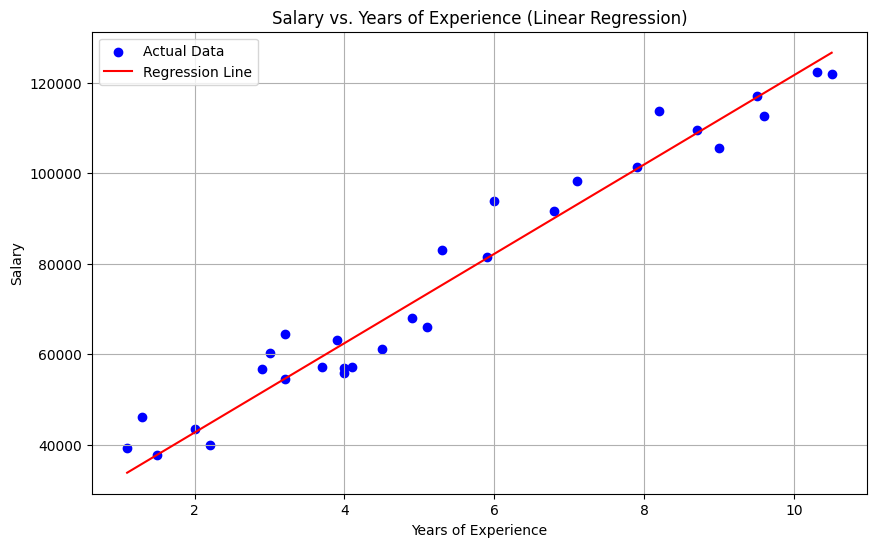

In [8]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Evaluate the model
mse = mean_squared_error(Y, Y_pred)
r2 = r2_score(Y, Y_pred)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, color='blue', label='Actual Data')
plt.plot(X, Y_pred, color='red', label='Regression Line')
plt.title('Salary vs. Years of Experience (Linear Regression)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)
plt.show()

## Making Predictions for New Data

In [9]:
# Example: Predict salary for a person with 12 years of experience
new_experience_1 = np.array([[12]])
predicted_salary_1 = model.predict(new_experience_1)
print(f"Predicted Salary for 12 years of experience: ${predicted_salary_1[0]:.2f}")

# Example: Predict salaries for multiple new experience values
new_experiences = np.array([[1.5], [5.0], [15.0]])
predicted_salaries = model.predict(new_experiences)

print("\nPredicted Salaries for new experience values:")
for i, experience in enumerate(new_experiences):
  print(f"Years of Experience: {experience[0]:.1f}, Predicted Salary: ${predicted_salaries[i]:.2f}")

Predicted Salary for 12 years of experience: $141433.84

Predicted Salaries for new experience values:
Years of Experience: 1.5, Predicted Salary: $37734.65
Years of Experience: 5.0, Predicted Salary: $72301.05
Years of Experience: 15.0, Predicted Salary: $171062.18
